In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Agents.xlsx to Agents (4).xlsx


In [ ]:
import pandas as pd
df_properties = pd.read_excel("Properties copy.xlsx")
df_sales_transactions = pd.read_excel("Sales Transaction.xlsx")
df_customers = pd.read_excel("Customers.xlsx")
df_locations = pd.read_excel("Location.xlsx")
df_agents = pd.read_excel("Agents.xlsx")

In [ ]:
df_agents['employment_status'] = df_agents['employment_status'].astype('str')

In [ ]:
df_agents['employment_status'] = df_agents['employment_status'].str.upper()

In [ ]:
df_customers['customer_name'] = df_customers['customer_name'].astype('str')
df_customers['customer_name'] = df_customers['customer_name'].str.upper()

In [ ]:
df_customers['income'] = df_customers['income'].astype('str')
df_customers['income'] = df_customers['income'].str.replace('£', '')
df_customers['income'] = df_customers['income'].str.replace(',', '')
df_customers['income'] = df_customers['income'].astype('float')

In [ ]:
df_customers['marital_status'] = df_customers['marital_status'].astype('str')
df_customers['marital_status'] = df_customers['marital_status'].str.upper()

In [ ]:
df_customers['first_time_buyer'] = df_customers['first_time_buyer'].astype('str')
df_customers['first_time_buyer'] = df_customers['first_time_buyer'].str.upper()

In [ ]:
df_sales_transactions['sale_status'] = df_sales_transactions['sale_status'].astype('str')
df_sales_transactions['sale_status'] = df_sales_transactions['sale_status'].str.upper()
df_sales_transactions['sale_price'] = df_sales_transactions['sale_price'].astype('str')
df_sales_transactions['sale_price'] = df_sales_transactions['sale_price'].str.replace('£', '')
df_sales_transactions['sale_price'] = df_sales_transactions['sale_price'].str.replace(',', '')
df_sales_transactions['sale_price'] = df_sales_transactions['sale_price'].astype('float')
df_sales_transactions['discount'] = df_sales_transactions['discount'].astype('str')
df_sales_transactions['discount'] = df_sales_transactions['discount'].str.replace('£', '')
df_sales_transactions['discount'] = df_sales_transactions['discount'].str.replace(',', '')
df_sales_transactions['discount'] = df_sales_transactions['discount'].astype('float')
df_sales_transactions['listing_price'] = df_sales_transactions['listing_price'].astype('str')
df_sales_transactions['listing_price'] = df_sales_transactions['listing_price'].str.replace('£', '')
df_sales_transactions['listing_price'] = df_sales_transactions['listing_price'].str.replace(',', '')
df_sales_transactions['listing_price'] = df_sales_transactions['listing_price'].astype('float')
df_sales_transactions = df_sales_transactions.drop(df_sales_transactions.index[21])

## Total Number of Properties Sold

In [ ]:
total_properties = df_sales_transactions[df_sales_transactions['sale_status'] == 'COMPLETED'].shape[0]
print(total_properties)

22


## Total Revenue of Sales

In [ ]:
total_sales_revenue = df_sales_transactions[df_sales_transactions['sale_status'] == 'COMPLETED']['sale_price'].sum()
print(total_sales_revenue)

8000000.0


## Average Selling Price

In [ ]:
avg_sales_revenue = df_sales_transactions[df_sales_transactions['sale_status'] == 'COMPLETED']['sale_price'].mean()
print(avg_sales_revenue)

363636.36363636365


## Median selling price

In [ ]:
median_sales_revenue = df_sales_transactions[df_sales_transactions['sale_status'] == 'COMPLETED']['sale_price'].median()
print(median_sales_revenue)

335000.0


## Average discount

In [ ]:
from numpy import average
average_discount = df_sales_transactions[df_sales_transactions['sale_status'] == 'COMPLETED']['discount'].mean()
print(average_discount)

9545.454545454546


## Average discount %

In [ ]:
total_discount = df_sales_transactions[df_sales_transactions['sale_status'] == 'COMPLETED']['discount'].sum()
print(total_discount)

210000.0


In [ ]:
avg_discount_pct = (average_discount / total_sales_revenue) * 100
print(avg_discount_pct)

0.11931818181818182


## Sales volume by month

In [ ]:
df_sales_transactions['sale_date'] = pd.to_datetime(df_sales_transactions['sale_date'])
df_sales_transactions['sale_year'] = df_sales_transactions['sale_date'].dt.year
df_sales_transactions['sale_month'] = df_sales_transactions['sale_date'].dt.month
df_sales_transactions['sale_day'] = df_sales_transactions['sale_date'].dt.day

/tmp/ipykernel_1704/257513138.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_sales_transactions['sale_date'] = pd.to_datetime(df_sales_transactions['sale_date'])


In [ ]:
df_sales_transactions = df_sales_transactions.drop(columns=['sale_date'])

In [ ]:
monthly_sales = df_sales_transactions.groupby(['sale_year', 'sale_month'])['sale_price'].sum()
print(monthly_sales)

sale_year  sale_month
2026       1              897000.0
           2              592000.0
           3              884000.0
           4              930000.0
           5             1698000.0
           6              773000.0
           7              948000.0
           8             1376000.0
           12             717000.0
Name: sale_price, dtype: float64


## Revenue by Month

In [ ]:
completed_sales = df_sales_transactions[df_sales_transactions['sale_status'] == 'COMPLETED']
monthly_completed_sales = completed_sales.groupby(['sale_year', 'sale_month']).size()
print(monthly_completed_sales)

sale_year  sale_month
2026       1             3
           2             2
           3             3
           4             2
           5             3
           6             2
           7             2
           8             4
           12            1
dtype: int64


In [ ]:
df_properties['property_type'] = df_properties['property_type'].astype('str')
df_properties['property_type'] = df_properties['property_type'].str.upper()

In [ ]:
df_properties['property_status'] = df_properties['property_status'].astype('str')
df_properties['property_status'] = df_properties['property_status'].str.upper()

## ***Which property type sells the most?***

In [ ]:
property_sold = df_properties[df_properties['property_status'] == 'SOLD'].groupby('property_type').size()
property_sold = property_sold.sort_values(ascending=False)
print(property_sold)

property_type
APARTMENT    7
HOUSE        6
CONDO        4
FLAT         4
dtype: int64


In [ ]:
df_sales_transactions['sale_price'].max()

660000.0

## ***Which property type generates the most revenue?***

In [ ]:
sales_property = pd.merge(df_sales_transactions, df_properties, on='property_id')
#Merging the two dataframes together

In [ ]:
revenue_by_property_type = sales_property[sales_property['sale_status'] == 'COMPLETED'].groupby('property_type')['sale_price'].sum()
most_revenue_property_type = revenue_by_property_type.sort_values(ascending=False)
print("Property type generating the most revenue:")
print(most_revenue_property_type)

Property type generating the most revenue:
property_type
HOUSE        3610000.0
APARTMENT    2100000.0
CONDO        1378000.0
FLAT          912000.0
Name: sale_price, dtype: float64


### ***Does property size influence selling price?***

In [ ]:
size_revenue = sales_property[sales_property['sale_status'] == 'COMPLETED'][['area_sqft','sale_price']]
print(size_revenue)

    area_sqft  sale_price
0         985    280000.0
1        1250    355000.0
2        2100    510000.0
3        1100    310000.0
4         650    218000.0
5         875    268000.0
6        1450    398000.0
7        1020    288000.0
8        2300    545000.0
9         950    282000.0
10       1850    420000.0
11       1150    328000.0
12        620    198000.0
13       2400    575000.0
14        890    262000.0
15       3100    660000.0
16        980    288000.0
17       1700    385000.0
18       1080    342000.0
19        700    208000.0
20       1280    365000.0
21       2100    515000.0


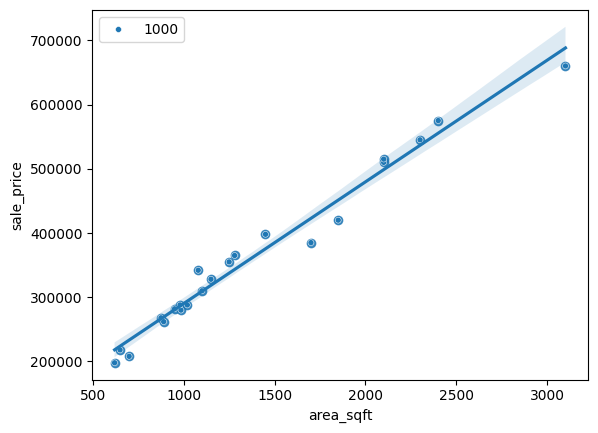

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.regplot(x='area_sqft', y='sale_price', data=size_revenue)
sns.scatterplot(x='area_sqft', y='sale_price', data=size_revenue, size=1000)
plt.show()

Standard Correlation Thresholds

**0.00 to 0.19**: Very weak or no relationship. The two variables do not move together.

**0.20 to 0.39**: Weak relationship. The variables show a slight connection.

**0.40 to 0.59**: Moderate relationship. The variables share a noticeable connection.

**0.60 to 0.79**: Strong relationship. The variables move together clearly.

**0.80 to 1.00**: Very strong relationship. The variables move together almost identically.

In [ ]:
sales_property['area_sqft'].corr(sales_property['sale_price'])

np.float64(0.9436066339683753)

So as the r value comes around 0.94(approx) this represents Property size has a strong positive correlation with selling price.

Larger properties tend to command higher selling prices, with the strength of this relationship measured through correlation and regression analysis. *However, property size should be evaluated alongside location, property type and other characteristics before determining its independent impact on selling price.*

## ***Does the number of bedrooms influence price?***

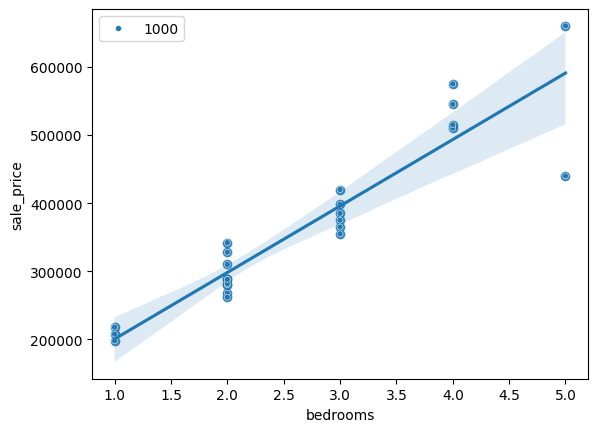

In [ ]:
sns.regplot(x='bedrooms',y='sale_price',data=sales_property)
sns.scatterplot(x='bedrooms',y='sale_price',data=sales_property,size=1000)
plt.show()

In [ ]:
sales_property['bedrooms'].corr(sales_property['sale_price'])

np.float64(0.9276969643747022)

The analysis identified a very strong positive relationship between the number of bedrooms and property price (r = 0.92). This suggests that larger-bedroom properties tend to command significantly higher prices. Therefore, bedroom count appears to be an important factor when assessing property value and could help the business understand pricing and identify higher-value property segments.

Although bedroom count has a very strong correlation with property price (r = 0.92), bedroom count is also strongly associated with property size. This suggests that part of the relationship between bedrooms and price may reflect the larger floor area typically associated with properties with more bedrooms. Further analysis is therefore required to isolate the individual contribution of bedroom count to property value.

## ***Which property type has the highest average discount?***

In [ ]:
highest_discount = sales_property[sales_property['sale_status']=='COMPLETED'].groupby('property_type')['discount'].sum()
print(highest_discount.sort_values(ascending=False))

property_type
HOUSE        95000.0
APARTMENT    55000.0
CONDO        32000.0
FLAT         28000.0
Name: discount, dtype: float64


## ***Which properties achieve the highest price per square foot?***

In [ ]:
sales_property['price_per_sqft'] = sales_property['sale_price'] / sales_property['area_sqft']

In [ ]:
highest_sale_price = sales_property[sales_property['sale_status']=='COMPLETED'].groupby('property_type')['price_per_sqft'].sum()
print(highest_sale_price.sort_values(ascending=False))

property_type
APARTMENT    2044.807602
HOUSE        1631.035934
FLAT         1234.235252
CONDO        1158.184998
Name: price_per_sqft, dtype: float64


## ***Which city generates the most revenue?***

In [ ]:
sales_location = pd.merge(sales_property, df_locations, on='location_id')
#Merging Sales Property Table to Location Table using Location_id

In [ ]:
most_revenue_city = sales_location[sales_location['sale_status'] == 'COMPLETED'].groupby('city')['sale_price'].sum()
print(most_revenue_city.sort_values(ascending=False))

city
London        3888000.0
Manchester    1998000.0
Birmingham    1444000.0
Bristol        670000.0
Name: sale_price, dtype: float64


## ***Which region has the highest average selling price?***

In [ ]:
highest_region_sales = sales_location[sales_location['sale_status'] == 'COMPLETED'].groupby('region')['sale_price'].mean()
print(highest_region_sales.sort_values(ascending=False))

region
Greater Manchester    499500.000000
Greater London        353454.545455
South West            335000.000000
West Midlands         288800.000000
Name: sale_price, dtype: float64


## ***Which areas have the highest price/sqft?***

In [ ]:
highest_postcode_per_sqft = sales_location[sales_location['sale_status'] == 'COMPLETED'].groupby('postcode')['price_per_sqft'].sum()
print(highest_postcode_per_sqft.sort_values(ascending=False))

postcode
SW1A    1086.986719
E14      884.667737
M1       762.577997
N1       632.226721
B5       616.497696
BS1      601.884058
B1       508.823529
SE1      449.859748
B15      285.156250
M20      239.583333
Name: price_per_sqft, dtype: float64


## ***Where are sales volumes highest?***

In [ ]:
highest_sale_vol_month_region = sales_location[sales_location['sale_status'] == 'COMPLETED'].groupby(['sale_year', 'sale_month', 'region']).size()
print(highest_sale_vol_month_region.sort_values(ascending=False))

sale_year  sale_month  region            
2026       1           Greater London        3
           8           West Midlands         3
           2           Greater London        2
           7           Greater London        2
           3           Greater London        2
                       Greater Manchester    1
           4           Greater London        1
           5           Greater London        1
           4           West Midlands         1
           5           Greater Manchester    1
                       South West            1
           6           West Midlands         1
                       Greater Manchester    1
           8           Greater Manchester    1
           12          South West            1
dtype: int64


## ***Which locations offer the strongest sales opportunity?***

In [ ]:
strong_sales_opportunity = sales_location[sales_location['sale_status'] == 'COMPLETED'].groupby('postcode').size()
print(strong_sales_opportunity.sort_values(ascending=False))

postcode
SW1A    4
M1      3
E14     3
B1      2
B5      2
BS1     2
SE1     2
N1      2
B15     1
M20     1
dtype: int64


In [ ]:
sales_customers = pd.merge(df_sales_transactions, df_customers, on = 'customer_id')
#Merging Sales Transaction to the Customers table

## ***First-time vs repeat buyers***

In [ ]:
first_time_buyer = sales_customers[(sales_customers['sale_status'] == 'COMPLETED') & (sales_customers['first_time_buyer'] == 'YES')]['customer_name']
print(first_time_buyer)

0         JOHN SMITH
1        SARAH JONES
3        EMILY DAVIS
5       PRIYA SHARMA
7       OLIVIA MOORE
11       AVA JACKSON
13        MIA HARRIS
15    ISABELLA LEWIS
17       AMELIA HALL
Name: customer_name, dtype: object


In [ ]:
repeat_buyer = sales_customers[(sales_customers['sale_status'] == 'COMPLETED') & (sales_customers['first_time_buyer'] == 'NO')]['customer_name']
print(repeat_buyer)

2       MICHAEL BROWN
4       ROBERT WILSON
6        JAMES TAYLOR
8       DANIEL MARTIN
9     SOPHIA ANDERSON
10     WILLIAM THOMAS
12       GEORGE WHITE
14       THOMAS CLARK
16       HENRY WALKER
18      CHARLES ALLEN
19        GRACE YOUNG
20          JACK KING
21        OSCAR SCOTT
Name: customer_name, dtype: object


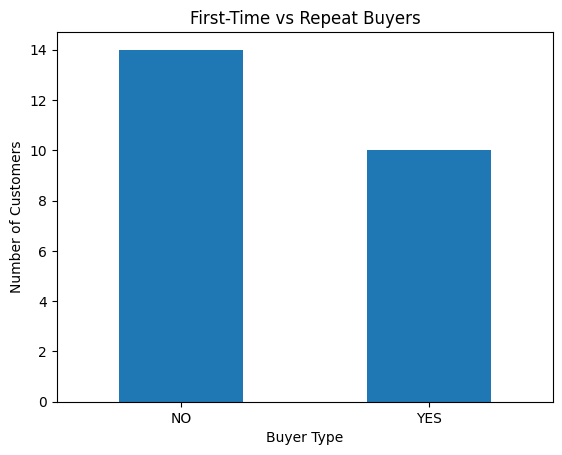

In [ ]:
import matplotlib.pyplot as plt

buyer_counts = sales_customers['first_time_buyer'].value_counts()
# value_counts() is a built-in method used to count the occurrences of unique
# values within a Series or a DataFrame column

buyer_counts.plot(kind='bar')

plt.title('First-Time vs Repeat Buyers')
plt.xlabel('Buyer Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

## ***Average property price purchased by age group***

In [ ]:
avg_prop_purchase_age = sales_customers[sales_customers['sale_status'] == 'COMPLETED'].groupby('age')['sale_price'].mean()
print(avg_prop_purchase_age)

age
25    385000.0
26    288000.0
27    328000.0
28    268000.0
29    355000.0
30    575000.0
31    310000.0
32    660000.0
33    282000.0
34    280000.0
35    208000.0
36    198000.0
38    365000.0
39    398000.0
41    420000.0
43    288000.0
44    515000.0
45    510000.0
47    545000.0
49    342000.0
52    218000.0
55    262000.0
Name: sale_price, dtype: float64


## ***Average income of buyers***

In [ ]:
avg_income_buyers = sales_customers[sales_customers['sale_status'] == 'COMPLETED']['income'].mean()
print(avg_income_buyers)

72863.63636363637


## ***Relationship between income and property price***

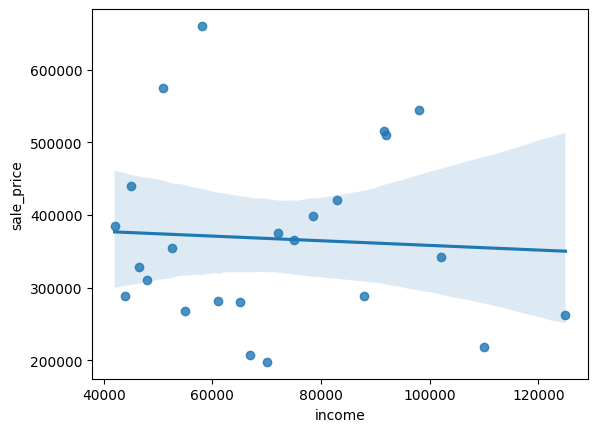

In [ ]:
sns.regplot(x='income',y='sale_price',data=sales_customers)
#sns.scatterplot(x='income',y='sale_price',data=sales_customers,size=1000)
plt.show()

In [ ]:
print(sales_customers['income'].corr(sales_customers['sale_price']))

-0.06037905801162146


The correlation coefficient between income and property price is calculated to be approximately **-0.06**. This indicates a very weak or no relationship, suggesting that there is little to no linear relationship between buyers' incomes and the sale prices of properties they purchase. The regression plot visually supports this, showing a very slight downward or flat trend. This weak correlation implies that income, by itself, is not a significant linear factor influencing property purchasing power and the value of properties acquired in this dataset.



## ***Which customer segments purchase higher-value properties?***

In [ ]:
avg_sale_price_by_occupation = sales_customers.groupby('occupation')['sale_price'].mean().sort_values(ascending=False)
print("Average Sale Price by Occupation:\n", avg_sale_price_by_occupation)

avg_sale_price_by_marital_status = sales_customers.groupby('marital_status')['sale_price'].mean().sort_values(ascending=False)
print("\nAverage Sale Price by Marital Status:\n", avg_sale_price_by_marital_status)

avg_sale_price_by_first_time_buyer = sales_customers.groupby('first_time_buyer')['sale_price'].mean().sort_values(ascending=False)
print("\nAverage Sale Price by First-Time Buyer Status:\n", avg_sale_price_by_first_time_buyer)

Average Sale Price by Occupation:
 occupation
Analyst                660000.0
Pharmacist             575000.0
Consultant             545000.0
Doctor                 515000.0
Accountant             510000.0
Finance Manager        420000.0
Administrator          385000.0
Engineer               381500.0
Sales Manager          375000.0
Nurse                  364000.0
Marketing Manager      355000.0
Business Consultant    342000.0
Designer               328000.0
Teacher                310000.0
Architect              288000.0
HR Manager             282000.0
Software Engineer      280000.0
Data Analyst           268000.0
Director               262000.0
Business Owner         218000.0
Project Manager        208000.0
IT Manager             198000.0
Name: sale_price, dtype: float64

Average Sale Price by Marital Status:
 marital_status
SINGLE     381700.0
MARRIED    357000.0
Name: sale_price, dtype: float64

Average Sale Price by First-Time Buyer Status:
 first_time_buyer
YES    388900.000000
NO

In [ ]:
sales_customers['payment_method'] = sales_customers['payment_method'].astype('str')
sales_customers['payment_method'] = sales_customers['payment_method'].str.upper()

## ***Mortgage vs cash purchases***

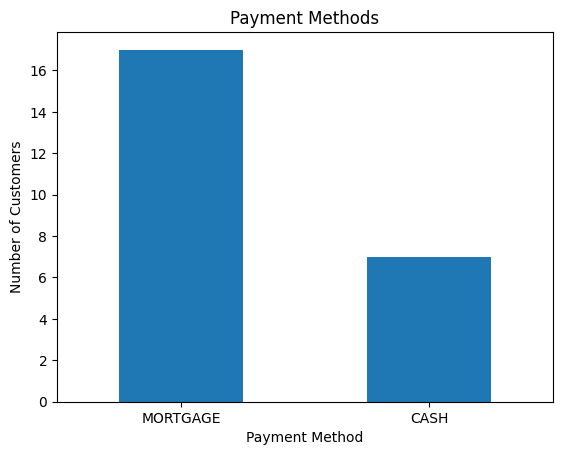

In [ ]:
payment_count = sales_customers['payment_method'].value_counts()
payment_count.plot(kind='bar')
plt.title('Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [331]:
sales_agent = pd.merge(df_sales_transactions, df_agents, on='agent_id')
#Merging Sales Transaction to the Agents

## ***Agent Revenue***

In [332]:
agent_revenue = sales_agent[sales_agent['sale_status'] == 'COMPLETED'].groupby('agent_name')['sale_price'].sum()
print(agent_revenue.sort_values(ascending=False))

agent_name
Oliver Brown       2868000.0
David Miller       1998000.0
Emma Wilson        1375000.0
Charlotte Davis     931000.0
George Taylor       828000.0
Name: sale_price, dtype: float64


## ***Agent Sales Volume***

In [333]:
agent_sales_volume = sales_agent[sales_agent['sale_status'] == 'COMPLETED'].groupby('agent_name').size()
print(agent_sales_volume.sort_values(ascending=False))

agent_name
Oliver Brown       6
Emma Wilson        5
David Miller       5
Charlotte Davis    3
George Taylor      3
dtype: int64


## ***Average Deal Size***

In [334]:
average_deal_size = sales_agent[sales_agent['sale_status'] == 'COMPLETED'].groupby('agent_name')['sale_price'].mean()
print(average_deal_size.sort_values(ascending=False))

agent_name
Oliver Brown       478000.000000
David Miller       399600.000000
Charlotte Davis    310333.333333
George Taylor      276000.000000
Emma Wilson        275000.000000
Name: sale_price, dtype: float64
